# Aggregation

This notebook is an experiment to determine the effect of aggregating before and after identification in a survey like AllWISE.

We have a 3 arcmin x 3 arcmin frame. We will assume $r$ of the citizen scientists click the correct object, and $1 - r$ click an incorrect object. We will assume that they click with a Gaussian distribution on the true centre of the object and that the size of this Gaussian matches the PSF of WISE (about 5"). For a list of object coordinates, we'll assume that the first object is the correct choice.

The whole sky is ~41253 sq deg, and there are 747 million sources in AllWISE. That gives a source density of 18107/sq deg, or 5.03/sq arcmin. That means there are about 45 sources per image.

In [124]:
import astropy.units as u

In [135]:
N_OBJECTS_PER_FRAME = 45
CLICK_SPREAD = 5 * u.arcsec
N_CLICKS = 5
FRAME_SIZE = 3 * u.arcmin
CLICK_RATE_CORRECT = 0.8
CLICK_RATE_INCORRECT = 0.2

In [136]:
import numpy as np
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from scipy import stats
from scipy import ndimage

In [137]:
def generate_objects(
    n=N_OBJECTS_PER_FRAME,
    size: u.Quantity[u.arcmin]=FRAME_SIZE,
    rng: np.random.Generator=None) -> list[tuple[float, float]]:
    if not rng:
        rng = np.random.default_rng()
    coords = []
    for _ in range(n):
        coords.append(tuple(rng.uniform(0, size.to(u.arcmin).value) for _ in range(2)))
    return coords

In [138]:
def generate_clicks(
        objects: list[tuple[float, float]],
        n_clicks: int=N_CLICKS,
        rate_correct: float=CLICK_RATE_CORRECT,
        rate_incorrect: float=CLICK_RATE_INCORRECT,
        spread: u.Quantity[u.arcsec]=CLICK_SPREAD,
        rng: np.random.Generator=None) -> list[tuple[float, float]]:
    if abs(rate_correct + rate_incorrect - 1) > 1e-6:
        raise ValueError("Rates do not sum to 1")
    if not rng:
        rng = np.random.default_rng()
    n_correct = round(rate_correct * n_clicks)
    n_incorrect = round(rate_incorrect * n_clicks)
    coords = []
    for _ in range(n_correct):
        coords.append(objects[0] + rng.normal(scale=spread.to(u.arcmin).value, size=(2,)))
    for _ in range(n_incorrect):
        coords.append(objects[1] + rng.normal(scale=spread.to(u.arcmin).value, size=(2,)))
    assert len(coords) == n_clicks
    return coords

Let's try out plotting this to see what it looks like.

In [139]:
def plot(objects, clicks):
    plt.scatter(*np.transpose(objects), c='red')
    plt.scatter(*np.transpose(clicks), c='blue', marker='x')

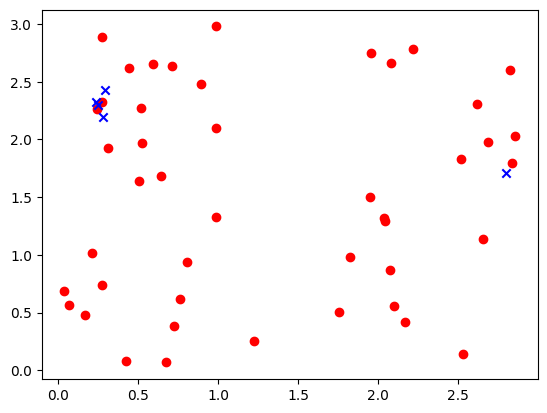

In [140]:
objects = generate_objects()
clicks = generate_clicks(objects)
plot(objects, clicks)

OK, now we can implement both aggregation methods. I cribbed the method from RGZ DR1 and edited it to fit this code.

In [141]:
def dr1_aggregate(clicks):
    clicks = np.array(clicks) * 200
    xmin, ymin = clicks.min(axis=0)
    xmax, ymax = clicks.max(axis=0)
    X, Y = np.mgrid[xmin:xmax, ymin:ymax]
    positions = np.vstack([X.ravel(), Y.ravel()])
    try:
        # Compute the kernel density estimate
        kernel = stats.gaussian_kde(clicks.T)
    except stats.LinAlgError as e:
        raise NotImplementedError("KDE failed.") from e
        # TODO
        # print 'LinAlgError in KD estimation for {0}'.format(zid,x_exists,y_exists)
        # logging.warning('LinAlgError in KD estimation for {0}'.format(zid,x_exists,y_exists))
        # for k,v in answer.iteritems():
        #     if v['ind'] == xk:
        #         xpeak, ypeak = np.mean(x_exists), np.mean(y_exists)
        #         answer[k]['ir'] = (xpeak, ypeak)
        #         # Count the number of clicks within 3"
        #         agreed = 0
        #         for x0, y0 in zip(x_exists, y_exists):
        #             if np.sqrt(np.square(xpeak-x0)+np.square(ypeak-y0)) <= (xmax-xmin)/60.:
        #                 agreed += 1
        #         answer[k]['n_ir'] = agreed
        #         answer[k]['ir_level'] = 1.0*agreed/len(xv)
        #         answer[k]['ir_flag'] = 0
        # continue
    
    kp = kernel(positions)
    if np.isnan(kp).sum() > 0:
        raise NotImplementedError("Colinear points.")
        # acp = collinearity.collinear(x_exists, y_exists)
        # if len(acp) > 0:
        #     output = 'There are {0:d} unique points for {1} (source no. {2:d} in the field), but all are co-linear; KDE estimate does not work.'.format( \
        #         len(Counter(x_exists)),zid,xk)
        # else:
        #     output = 'There are NaNs in the KDE for {0} (source no. {1:d} in the field), but points are not co-linear.'.format(zid,xk)
        # logging.info(output)
        
        # for k,v in answer.iteritems():
        #     if v['ind'] == xk:
        #         xpeak, ypeak = np.mean(x_exists), np.mean(y_exists)
        #         answer[k]['ir'] = (xpeak, ypeak)
        #         # Count the number of clicks within 3"
        #         agreed = 0
        #         for x0, y0 in zip(x_exists, y_exists):
        #             if np.sqrt(np.square(xpeak-x0)+np.square(ypeak-y0)) <= (xmax-xmin)/60.:
        #                 agreed += 1
        #         answer[k]['n_ir'] = agreed
        #         answer[k]['ir_level'] = 1.0*agreed/len(xv)
        #         answer[k]['ir_flag'] = 0
        
    Z = np.reshape(kp.T, X.shape)
    neighborhood = np.ones((10, 10))
    local_max = (ndimage.maximum_filter(Z, footprint=neighborhood) == Z)
    background = (Z == 0)
    eroded_background = ndimage.binary_erosion(background, structure=neighborhood, border_value=1)
    detected_peaks = local_max ^ eroded_background
    
    npeaks = detected_peaks.sum()
    
    try:
        xpeak = float(X[Z == Z.max()][0])
        ypeak = float(Y[Z == Z.max()][0])
        # peak_height = Z[int(xpeak) - 1, int(ypeak) - 1]
    except IndexError:
        raise

    return xpeak / 200, ypeak / 200

In [142]:
def plot(objects, clicks, agg):
    plt.scatter(*np.transpose(objects), c='red')
    plt.scatter(*np.transpose(clicks), c='blue', marker='x')
    plt.scatter(*agg, c='black', marker='o')

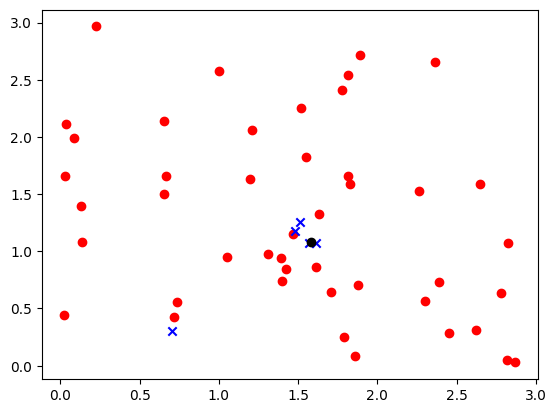

In [152]:
objects = generate_objects()
clicks = generate_clicks(objects)
plot(objects, clicks, dr1_aggregate(clicks))